# Clase: Pipeline de Ciencia de Datos con hogares_censo2024.csv

Objetivo de la clase:
1. Construir una muestra educacional representativa.
2. Ejecutar limpieza completa (faltantes, duplicados y anomalias).
3. Aplicar transformacion avanzada (normalizacion, encoding e ingenieria de caracteristicas).
4. Entrenar modelos y comparar metricas para elegir una tarea de prediccion util.

## 1) Librerias y configuracion

In [11]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

data_candidates = [
    Path('Actividad14/hogares_censo2024.csv'),
    Path('hogares_censo2024.csv'),
    Path('../Actividad14/hogares_censo2024.csv'),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)
if DATA_PATH is None:
    attempted = '\n'.join(str(p.resolve()) for p in data_candidates)
    raise FileNotFoundError(
        'No se encontro hogares_censo2024.csv. Rutas probadas:\n' + attempted
    )

OUTPUT_DIR = DATA_PATH.parent / 'output_hogares'
SAMPLE_SIZE = 120_000
RANDOM_STATE = 42

ID_COLS = ['id_vivienda', 'id_hogar']
TARGET_COL = 'tipologia_hogar'

CATEGORICAL_COLS = [
    'region',
    'provincia',
    'comuna',
    'comuna_bajo_umbral',
    'area',
    'tipo_operativo',
    'p12_tenencia_viv',
    'p13_comb_cocina',
    'p14_comb_calefaccion',
    'p15a_serv_tel_movil',
    'p15b_serv_compu',
    'p15c_serv_tablet',
    'p15d_serv_internet_fija',
    'p15e_serv_internet_movil',
    'p15f_serv_internet_satelital',
]

SERVICE_COLS = [
    'p15a_serv_tel_movil',
    'p15b_serv_compu',
    'p15c_serv_tablet',
    'p15d_serv_internet_fija',
    'p15e_serv_internet_movil',
    'p15f_serv_internet_satelital',
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Configuracion lista')
print('DATA_PATH:', DATA_PATH.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())

Configuracion lista
DATA_PATH: C:\xampp\htdocs\codigo\Actividad14\hogares_censo2024.csv
OUTPUT_DIR: C:\xampp\htdocs\codigo\Actividad14\output_hogares


## 2) Carga y exploracion rapida
Teoria corta: antes de modelar, siempre revisamos tamano, columnas, tipos y faltantes.

In [12]:
df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8')
print('Shape original:', df.shape)
display(df.head(3))
display(df.dtypes.to_frame('dtype').T)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame('missing_%').head(10))

Shape original: (6622597, 18)


,id_vivienda,id_hogar,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,p12_tenencia_viv,p13_comb_cocina,p14_comb_calefaccion,p15a_serv_tel_movil,p15b_serv_compu,p15c_serv_tablet,p15d_serv_internet_fija,p15e_serv_internet_movil,p15f_serv_internet_satelital,tipologia_hogar
0,1,1,5,58,5802,2,1,2,4.0,1.0,8.0,1.0,2.0,2.0,2.0,1.0,2.0,5.0
1,2,1,4,43,4303,2,2,2,9.0,1.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,7.0
2,3,1,11,112,11202,1,1,2,3.0,1.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,4.0


,id_vivienda,id_hogar,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,p12_tenencia_viv,p13_comb_cocina,p14_comb_calefaccion,p15a_serv_tel_movil,p15b_serv_compu,p15c_serv_tablet,p15d_serv_internet_fija,p15e_serv_internet_movil,p15f_serv_internet_satelital,tipologia_hogar
dtype,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


,missing_%
p13_comb_cocina,0.39
p12_tenencia_viv,0.39
p15f_serv_internet_satelital,0.39
tipologia_hogar,0.39
p15e_serv_internet_movil,0.39
p15d_serv_internet_fija,0.39
p15c_serv_tablet,0.39
p15b_serv_compu,0.39
p15a_serv_tel_movil,0.39
p14_comb_calefaccion,0.39


## 3) Muestra representativa educacional
Teoria corta: usar todo el censo en clases puede ser pesado. Creamos una muestra estratificada por region y clase objetivo para mantener representatividad.

In [5]:
work = df.dropna(subset=[TARGET_COL]).copy()
work[TARGET_COL] = work[TARGET_COL].astype(int)
work['_strata'] = work['region'].astype(str) + '_' + work[TARGET_COL].astype(str)

weights = work['_strata'].value_counts(normalize=True)
target_counts = (weights * SAMPLE_SIZE).round().astype(int)

samples = []
for stratum, cnt in target_counts.items():
    if cnt <= 0:
        continue
    chunk = work[work['_strata'] == stratum]
    take = min(cnt, len(chunk))
    samples.append(chunk.sample(n=take, random_state=RANDOM_STATE))

sample = pd.concat(samples, ignore_index=True).drop(columns=['_strata'], errors='ignore')

if len(sample) > SAMPLE_SIZE:
    sample = sample.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

sample_path = OUTPUT_DIR / 'hogares_censo2024_muestra_educacional.csv'
sample.to_csv(sample_path, index=False, encoding='utf-8')

print('Shape muestra:', sample.shape)
print('Guardado en:', sample_path)
display(sample[[TARGET_COL, 'region']].head())

Shape muestra: (119999, 18)
Guardado en: output_hogares\hogares_censo2024_muestra_educacional.csv


,tipologia_hogar,region
0,4,13
1,4,13
2,4,13
3,4,13
4,4,13


## 4) Limpieza de datos
Incluye: duplicados, anomalias codificadas (-99, -88, -77, 0), faltantes e integridad del target.

In [6]:
clean = sample.copy()
info = {}

info['rows_before'] = int(len(clean))
info['duplicates_removed'] = int(clean.duplicated().sum())
clean = clean.drop_duplicates()

for col in CATEGORICAL_COLS + [TARGET_COL]:
    clean[col] = pd.to_numeric(clean[col], errors='coerce')

anomaly_count = 0
for col in CATEGORICAL_COLS:
    mask = clean[col].isin([-99, -88, -77, 0])
    anomaly_count += int(mask.sum())
    clean.loc[mask, col] = np.nan

for col in CATEGORICAL_COLS:
    if clean[col].isna().any():
        mode = clean[col].mode(dropna=True)
        if not mode.empty:
            clean[col] = clean[col].fillna(mode.iloc[0])

info['target_missing_removed'] = int(clean[TARGET_COL].isna().sum())
clean = clean.dropna(subset=[TARGET_COL])
clean[TARGET_COL] = clean[TARGET_COL].astype(int)

info['coded_anomalies_replaced'] = int(anomaly_count)
info['rows_after'] = int(len(clean))

print(json.dumps(info, indent=2))
display((clean.isna().mean() * 100).round(3).sort_values(ascending=False).head(10))

{
  "rows_before": 119999,
  "duplicates_removed": 0,
  "target_missing_removed": 0,
  "coded_anomalies_replaced": 1017,
  "rows_after": 119999
}


id_vivienda           0.0
id_hogar              0.0
region                0.0
provincia             0.0
comuna                0.0
comuna_bajo_umbral    0.0
area                  0.0
tipo_operativo        0.0
p12_tenencia_viv      0.0
p13_comb_cocina       0.0
dtype: float64

## 5) Transformacion avanzada
Teoria corta:
- Ingenieria de caracteristicas: agregamos señales utiles.
- Normalizacion: escala comparable para variables numericas.
- Encoding: conversion de categoricas para modelos.

In [7]:
data = clean.copy()

for c in SERVICE_COLS:
    data[c] = pd.to_numeric(data[c], errors='coerce')

service_yes = [(data[c] == 1).astype(int) for c in SERVICE_COLS]
data['n_servicios_digitales'] = np.sum(service_yes, axis=0)
data['internet_any'] = (((data['p15d_serv_internet_fija'] == 1) | (data['p15e_serv_internet_movil'] == 1)).astype(int))
data['hogares_por_vivienda'] = data.groupby('id_vivienda')['id_hogar'].transform('count')
data['es_urbano'] = (data['area'] == 1).astype(int)

model_features_cat = CATEGORICAL_COLS
model_features_num = ['n_servicios_digitales', 'internet_any', 'hogares_por_vivienda', 'es_urbano']

X = data[model_features_cat + model_features_num]
y = data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, model_features_cat),
    ('num', num_pipe, model_features_num)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print('Matriz train transformada:', X_train_t.shape)
print('Matriz test transformada:', X_test_t.shape)

Matriz train transformada: (95999, 462)
Matriz test transformada: (24000, 462)


## 6) Modelado y comparacion de metricas
Probamos dos modelos clasicos para clase: Logistic Regression y Random Forest.

In [8]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=600, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=250, max_depth=18, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    )
}

rows = []
reports = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1w = f1_score(y_test, pred, average='weighted')
    rows.append({'model': name, 'accuracy': round(float(acc), 4), 'f1_weighted': round(float(f1w), 4)})
    reports[name] = classification_report(y_test, pred, output_dict=True, zero_division=0)

metrics_df = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False)
display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / 'metricas_modelos_tipologia_hogar.csv', index=False, encoding='utf-8')

best_model = metrics_df.iloc[0]['model']
best_report = pd.DataFrame(reports[best_model]).T
best_report.to_csv(OUTPUT_DIR / f"reporte_clasificacion_{best_model.lower()}.csv", encoding='utf-8')

print('Mejor modelo en este objetivo:', best_model)

,model,accuracy,f1_weighted
0,LogisticRegression,0.3539,0.2711
1,RandomForest,0.3553,0.2435


Mejor modelo en este objetivo: LogisticRegression


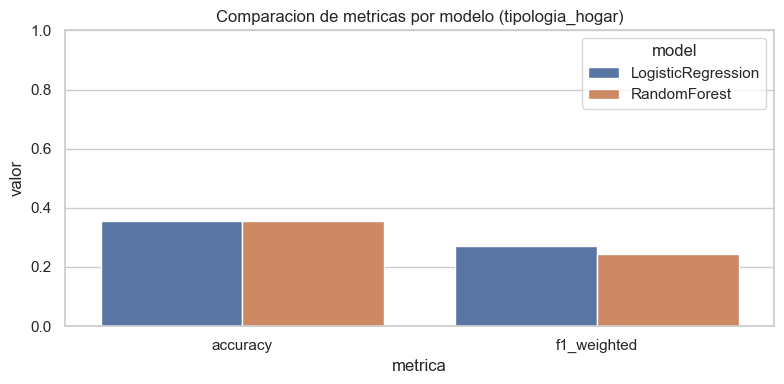

In [9]:
plt.figure(figsize=(8, 4))
plot_df = metrics_df.melt(id_vars='model', value_vars=['accuracy', 'f1_weighted'], var_name='metrica', value_name='valor')
sns.barplot(data=plot_df, x='metrica', y='valor', hue='model')
plt.ylim(0, 1)
plt.title('Comparacion de metricas por modelo (tipologia_hogar)')
plt.tight_layout()
plt.show()

## 7) Objetivo alternativo recomendado para clase
Prediccion binaria de internet fija (si/no).
En este dataset suele dar mejor desempeno y es mas facil de interpretar en clase.

In [10]:
df_bin = data[data['p15d_serv_internet_fija'].isin([1, 2])].copy()
df_bin['target_internet_fija'] = (df_bin['p15d_serv_internet_fija'] == 1).astype(int)

cat_cols_bin = [
    'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo',
    'p12_tenencia_viv', 'p13_comb_cocina', 'p14_comb_calefaccion', 'tipologia_hogar'
]
num_cols_bin = ['n_servicios_digitales', 'internet_any', 'hogares_por_vivienda', 'es_urbano']

Xb = df_bin[cat_cols_bin + num_cols_bin]
yb = df_bin['target_internet_fija']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=RANDOM_STATE, stratify=yb
)

prep_bin = ColumnTransformer([
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_bin),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols_bin),
])

rows_bin = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep_bin), ('model', model)])
    pipe.fit(Xb_train, yb_train)
    pred = pipe.predict(Xb_test)
    rows_bin.append({
        'model': name,
        'accuracy': round(float(accuracy_score(yb_test, pred)), 4),
        'f1_weighted': round(float(f1_score(yb_test, pred, average='weighted')), 4),
        'f1_positive': round(float(f1_score(yb_test, pred)), 4),
        'positive_ratio': round(float(yb.mean()), 4)
    })

metrics_bin = pd.DataFrame(rows_bin).sort_values('f1_positive', ascending=False)
display(metrics_bin)
metrics_bin.to_csv(OUTPUT_DIR / 'metricas_modelos_internet_fija.csv', index=False, encoding='utf-8')

,model,accuracy,f1_weighted,f1_positive,positive_ratio
0,LogisticRegression,0.8839,0.8825,0.9121,0.6442
1,RandomForest,0.8806,0.8789,0.9101,0.6442


## 8) Interpretacion en lenguaje comun
- Si un modelo tiene mejor **F1** y **accuracy**, esta clasificando mejor los hogares en ese objetivo.
- En esta base, normalmente es mas facil predecir **internet fija (si/no)** que la **tipologia_hogar** completa, porque el segundo problema es multiclase y mas complejo.
- Para clase: puedes mostrar ambos casos para comparar dificultad real de problemas de ML.
- Regla docente: no quedarse solo con accuracy; revisar tambien F1, especialmente cuando hay desbalance de clases.